In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score, classification_report , roc_curve, auc, confusion_matrix

In [55]:
diabetes = pd.read_csv('diabetes.csv')

In [56]:
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [57]:
diabetes.shape

(768, 9)

In [58]:
diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [59]:
diabetes['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [60]:
diabetes.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [61]:
x = diabetes.drop(columns='Outcome', axis=1)
y = diabetes['Outcome']

X_temp, X_test, y_temp, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=98)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=98)

print("Train Data Shape:", X_train.shape)
print("Validation Data Shape:", X_val.shape)
print("Test Data Shape:", X_test.shape)

Train Data Shape: (460, 8)
Validation Data Shape: (154, 8)
Test Data Shape: (154, 8)


In [62]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [63]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'poly'],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'degree': [2, 3] # Checking Quadratic vs Cubic for Poly
}

svm_model = SVC(random_state=98, class_weight='balanced')

grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)

print("Starting strict tuning (Linear & Poly only) with BALANCED weights.")
grid_search.fit(X_train_scaled, y_train)

print("\n--- RESULTS ---")
print("Best Parameters Found:", grid_search.best_params_)
print("Best Cross-Validation F1-Score: {:.4f}".format(grid_search.best_score_))

best_model = grid_search.best_estimator_

# Validation set par check (unseen subset 1)
val_prediction = best_model.predict(X_val_scaled)
print('\n--- VALIDATION DATA REPORT ---')
print(classification_report(y_val, val_prediction, target_names=['No Diabetes (0)', 'Diabetes (1)']))

# Final Test set par check (unseen subset 2)
test_prediction = best_model.predict(X_test_scaled)
print('\n--- TEST DATA REPORT (The Final Truth) ---')
print(classification_report(y_test, test_prediction, target_names=['No Diabetes (0)', 'Diabetes (1)']))

Starting strict tuning (Linear & Poly only) with BALANCED weights.

--- RESULTS ---
Best Parameters Found: {'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross-Validation F1-Score: 0.6464

--- VALIDATION DATA REPORT ---
                 precision    recall  f1-score   support

No Diabetes (0)       0.81      0.83      0.82       100
   Diabetes (1)       0.67      0.65      0.66        54

       accuracy                           0.77       154
      macro avg       0.74      0.74      0.74       154
   weighted avg       0.76      0.77      0.77       154


--- TEST DATA REPORT (The Final Truth) ---
                 precision    recall  f1-score   support

No Diabetes (0)       0.86      0.79      0.82       100
   Diabetes (1)       0.66      0.76      0.71        54

       accuracy                           0.78       154
      macro avg       0.76      0.77      0.76       154
   weighted avg       0.79      0.78      0.78       154



Training Linear and Poly models...


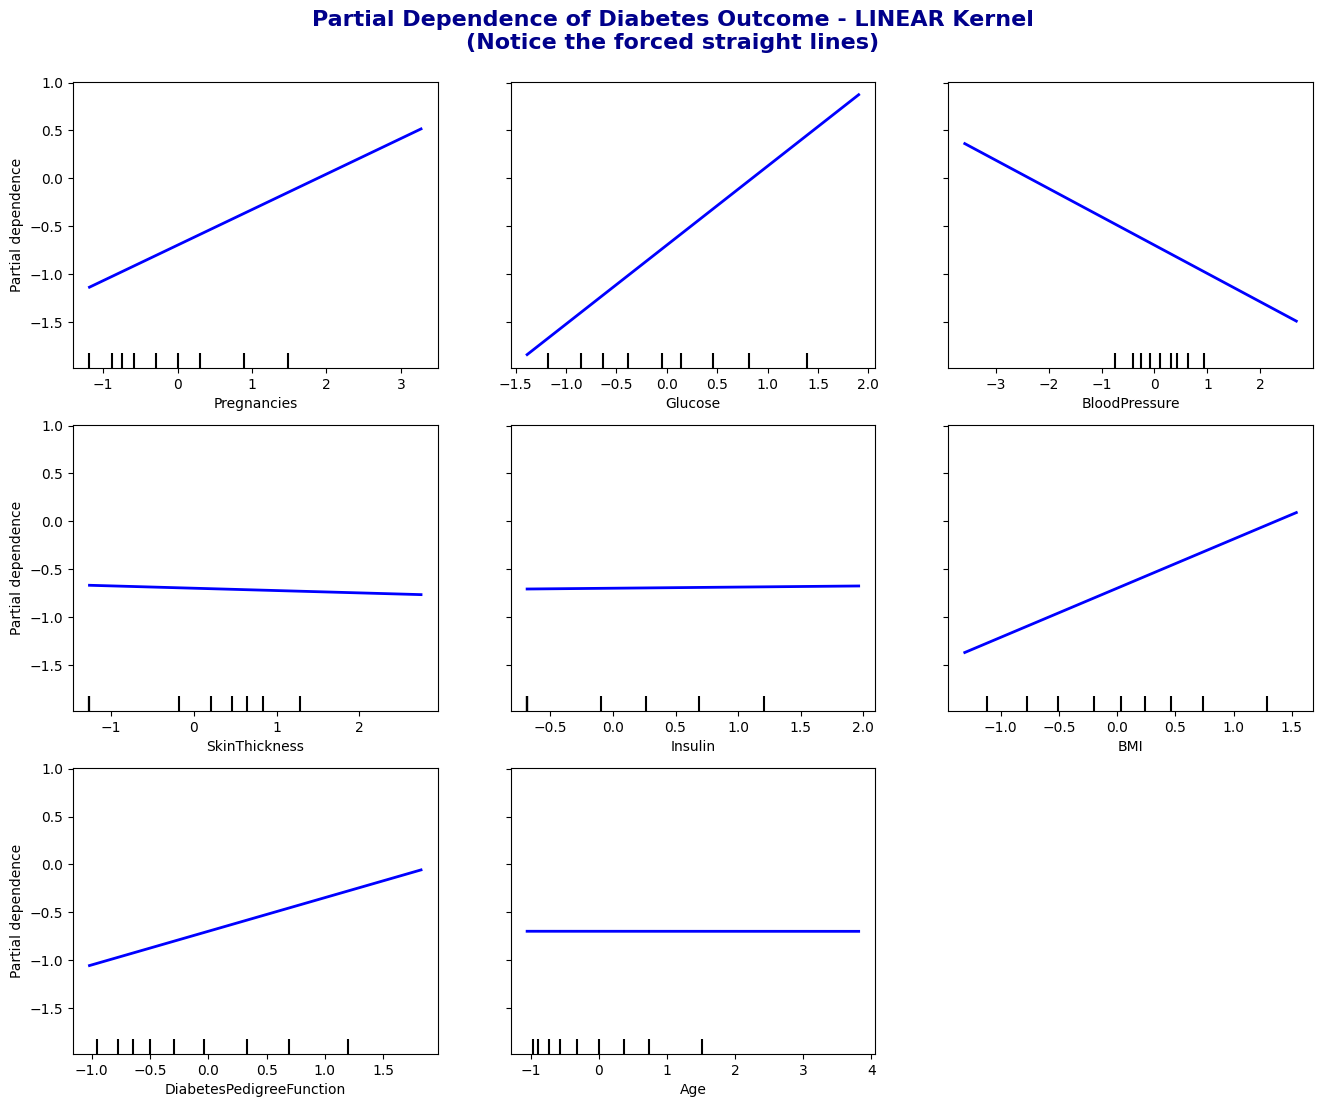

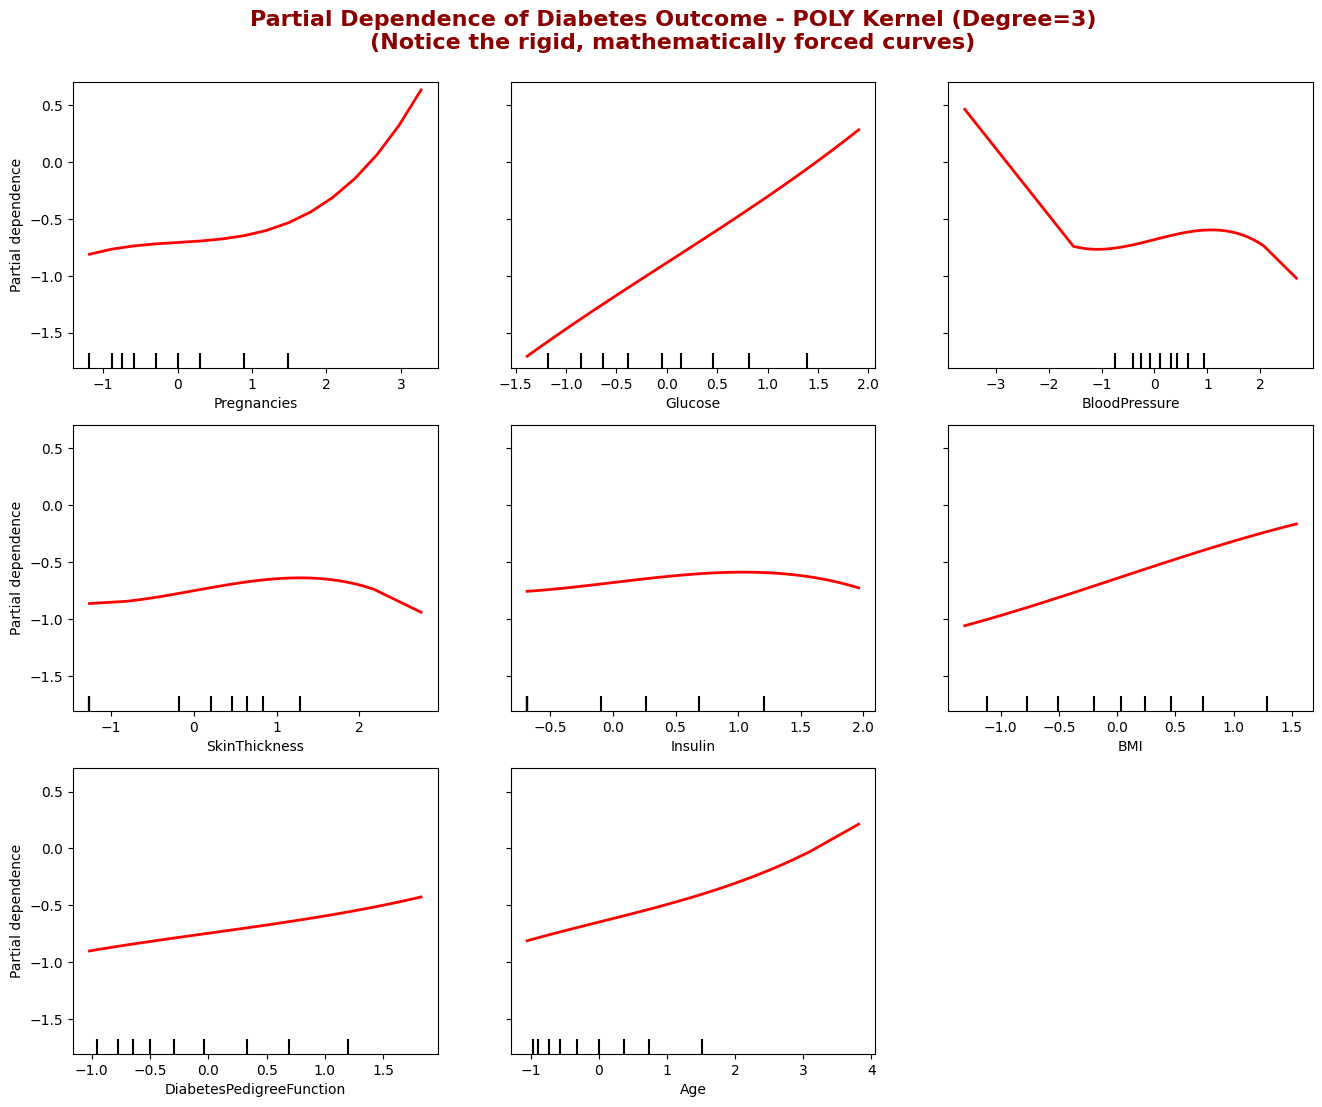

In [64]:
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.inspection import PartialDependenceDisplay

# 1. Force train explicitly for Linear and Poly
print("Training Linear and Poly models...")
svm_linear = SVC(kernel='linear', C=1, random_state=98)
svm_linear.fit(X_train_scaled, y_train)

svm_poly = SVC(kernel='poly', C=1, degree=3, random_state=98)
svm_poly.fit(X_train_scaled, y_train)

feature_names = x.columns.tolist()

# 2. PLOT 1: The LINEAR Reality
fig_linear, ax_linear = plt.subplots(figsize=(16, 12))
fig_linear.suptitle('Partial Dependence of Diabetes Outcome - LINEAR Kernel\n(Notice the forced straight lines)', fontsize=16, fontweight='bold', color='darkblue')

PartialDependenceDisplay.from_estimator(
    estimator=svm_linear,
    X=X_train_scaled,
    features=range(8),
    feature_names=feature_names,
    kind='average',
    ax=ax_linear,
    line_kw={'color': 'blue', 'linewidth': 2}
)
plt.subplots_adjust(top=0.92)
plt.show()

# 3. PLOT 2: The POLY Reality
fig_poly, ax_poly = plt.subplots(figsize=(16, 12))
fig_poly.suptitle('Partial Dependence of Diabetes Outcome - POLY Kernel (Degree=3)\n(Notice the rigid, mathematically forced curves)', fontsize=16, fontweight='bold', color='darkred')

PartialDependenceDisplay.from_estimator(
    estimator=svm_poly,
    X=X_train_scaled,
    features=range(8),
    feature_names=feature_names,
    kind='average',
    ax=ax_poly,
    line_kw={'color': 'red', 'linewidth': 2}
)
plt.subplots_adjust(top=0.92)
plt.show()

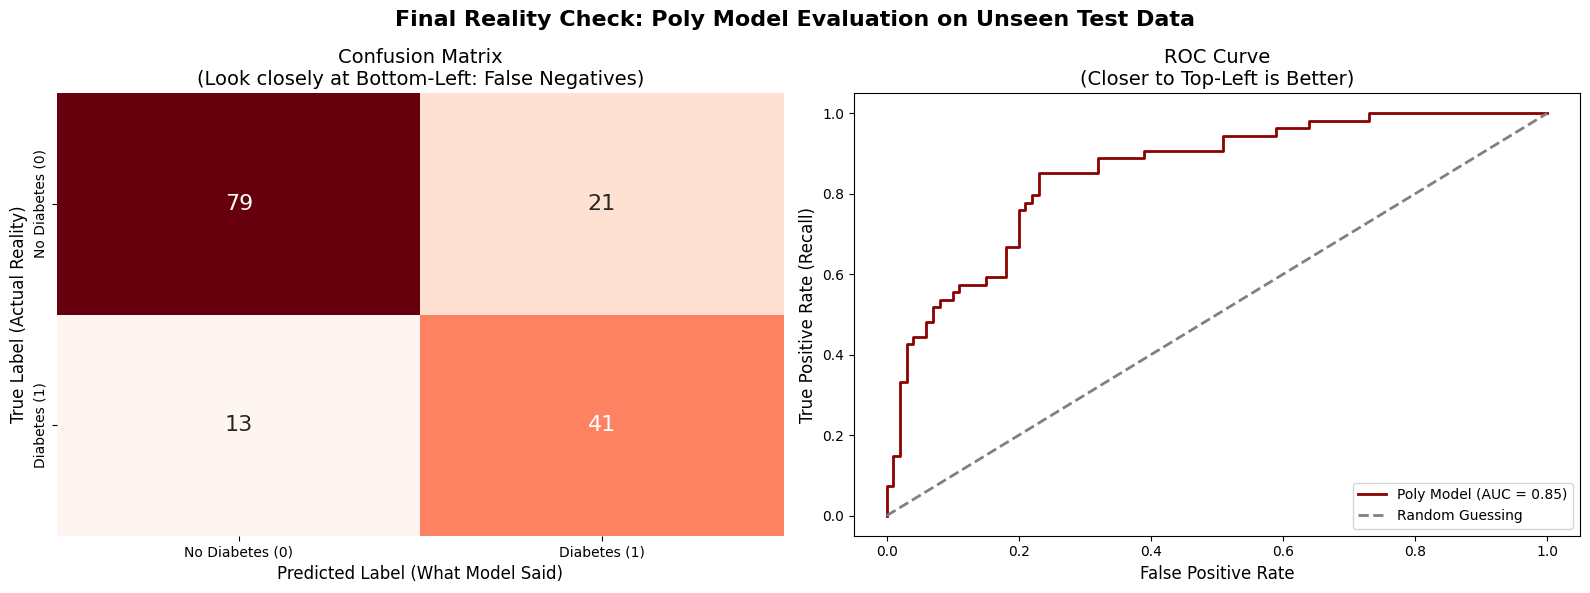


CLASSIFICATION REPORT (The Breakdown)
                 precision    recall  f1-score   support

No Diabetes (0)       0.86      0.79      0.82       100
   Diabetes (1)       0.66      0.76      0.71        54

       accuracy                           0.78       154
      macro avg       0.76      0.77      0.76       154
   weighted avg       0.79      0.78      0.78       154



In [65]:
test_predictions = best_model.predict(X_test_scaled)
test_probabilities = best_model.decision_function(X_test_scaled) # For ROC Curve

cm = confusion_matrix(y_test, test_predictions)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Final Reality Check: Poly Model Evaluation on Unseen Test Data', fontsize=16, fontweight='bold')

# --- PLOT 1: The Confusion Matrix ---
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False, ax=ax[0], annot_kws={"size": 16})
ax[0].set_title('Confusion Matrix\n(Look closely at Bottom-Left: False Negatives)', fontsize=14)
ax[0].set_xlabel('Predicted Label (What Model Said)', fontsize=12)
ax[0].set_ylabel('True Label (Actual Reality)', fontsize=12)
ax[0].xaxis.set_ticklabels(['No Diabetes (0)', 'Diabetes (1)'])
ax[0].yaxis.set_ticklabels(['No Diabetes (0)', 'Diabetes (1)'])

# --- PLOT 2: The ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, test_probabilities)
roc_auc = auc(fpr, tpr)

ax[1].plot(fpr, tpr, color='darkred', lw=2, label=f'Poly Model (AUC = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guessing')
ax[1].set_title('ROC Curve\n(Closer to Top-Left is Better)', fontsize=14)
ax[1].set_xlabel('False Positive Rate', fontsize=12)
ax[1].set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# 4. The Brutal Text Report
print("\n" + "="*50)
print("CLASSIFICATION REPORT (The Breakdown)")
print("="*50)
print(classification_report(y_test, test_predictions, target_names=['No Diabetes (0)', 'Diabetes (1)']))